# Time Series Forecasting: Zero to Hero

Forecasting is supervised learning with an information deadline: every input and every
training label must have been available when the forecast was issued.

> **Prerequisites:** [`ml_foundations_zero_to_hero.ipynb`](ml_foundations_zero_to_hero.ipynb)
> on leakage and [`gradient_boosting_zero_to_hero.ipynb`](gradient_boosting_zero_to_hero.ipynb).

## Why the usual workflow needs care

- **Validate the task you will deploy.** Shuffled and chronological splits answer different
  questions. Their score difference also reflects different test periods, not a pure leakage penalty.
- **Calendar time is not row position.** The bike data has missing hours. Recover actual dates,
  regularize the grid, and specify how missing observations affect features and evaluation.
- **Baselines matter.** Compare models and naive forecasts on the same timestamps and origins.
- **The horizon determines availability.** A lag may be legal at one horizon and unavailable at
  another; training labels and weather observations have deadlines too.
- **Extrapolation depends on the model.** Averaging forests cannot exceed their training-target
  range. Boosting does not share that exact bound, but still has difficulty extending a trend.

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Dependencies, imports, reproducibility |
| **1. Theory from zero** | Temporal validation, features, baselines, extrapolation, encoding, horizons |
| **2. Worked example** | Bike demand: rolling one-hour forecasts with observed-history inputs |
| **3. The traps** | Window leakage, fair classical comparison, aging and unavailable weather |
| **4. Tough questions** | Twelve questions and three coding challenges |
| **5. Practice datasets** | Five datasets with briefs |
| **6. Reading the literature** | Sources and further reading |
| **Appendix** | Troubleshooting and a forecasting checklist |

## Evaluation contract

To predict target hour **t** at horizon **h**, the origin is **t-h**. We assume the demand
observation for that origin is already released. Real reporting delays must move the cutoff
earlier. Calendar attributes are known ahead of time; target-hour observed weather is excluded
from operational models. Models stay fixed within an evaluation block while observations become
available between forecasts. This is rolling forecasting, not a forecast of the entire block
issued at its start.

The final 20% of calendar time is an illustrative evaluation period. Repeated inspection of it
in this tutorial makes it unsuitable as an untouched final deployment test. For model selection,
use earlier temporal folds and reserve a fresh final period. Numerical results below are computed
from the current run rather than copied into the prose.

***
# Part 0 - Setup

In [1]:
# Install missing packages into this notebook's kernel environment.
# The executed notebook records exact package versions in the next cell.
import importlib.util
import subprocess
import sys

REQUIRED = [("numpy", "numpy"), ("pandas", "pandas>=2.2"),
            ("matplotlib", "matplotlib"), ("scipy", "scipy"),
            ("sklearn", "scikit-learn>=1.5"), ("statsmodels", "statsmodels>=0.14")]
missing = [package for module, package in REQUIRED if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
print("Setup complete. Existing installations are not automatically upgraded.")

Setup complete. Existing installations are not automatically upgraded.


In [2]:
import io
import time
import warnings
import zipfile
from pathlib import Path
from urllib.request import urlopen
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, TimeSeriesSplit, train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["figure.dpi"] = 100

def histgb(**kwargs):
    # Avoid the default shuffled early-stopping validation split.
    return HistGradientBoostingRegressor(random_state=RANDOM_STATE,
                                        early_stopping=False, **kwargs)

print("Python", sys.version.split()[0])
for package in ("numpy", "pandas", "matplotlib", "scipy", "scikit-learn", "statsmodels"):
    print(f"{package}=={version(package)}")

Python 3.13.14
numpy==2.5.2
pandas==3.0.5
matplotlib==3.11.1
scipy==1.18.1
scikit-learn==1.9.0
statsmodels==0.15.0


***
# Part 1 - Theory from zero

1. Why the rows are not exchangeable
2. The supervised framing: lags, rolling windows, calendar
3. **Temporal evaluation and random splits**
4. Validating properly: `TimeSeriesSplit` and walk-forward
5. **The baselines you must beat**, and the metrics that compare against them
6. **Extrapolation and trend**
7. Encoding time
8. **The horizon decides your features**

## 1.1 Time order and the information deadline

Autocorrelation, seasonal structure and distribution shifts make arbitrary shuffling a poor
simulation of forecasting future demand. However, high lag correlation alone does not prove
leakage: yesterday's observed demand is a legitimate predictor of tomorrow's demand.

We use the original [UCI Bike Sharing data](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)
because `dteday` and `hr` identify actual dates. The hourly grid is the dataset's local calendar
convention, without attempting a timezone/DST conversion. A production system should separately
define timezones, DST handling and observation release times.

Missing targets stay missing. For features only, we forward-fill the history: this is a
**persistence estimate**, not an observation or a zero-demand claim. Shifting happens after this
causal fill, so a feature at t uses no observations after its origin. Long gaps can make these
features stale; Part 2 reports how often the origin itself was unobserved.

17,379 observed target hours; 17,544 grid hours
2011-01-01 00:00:00 to 2012-12-31 23:00:00
Missing target hours: 165
Evaluation period starts: 2012-08-07 19:00:00
Correlation at   1 calendar hours: 0.8431
Correlation at   2 calendar hours: 0.5923
Correlation at  24 calendar hours: 0.8192
Correlation at 168 calendar hours: 0.8762


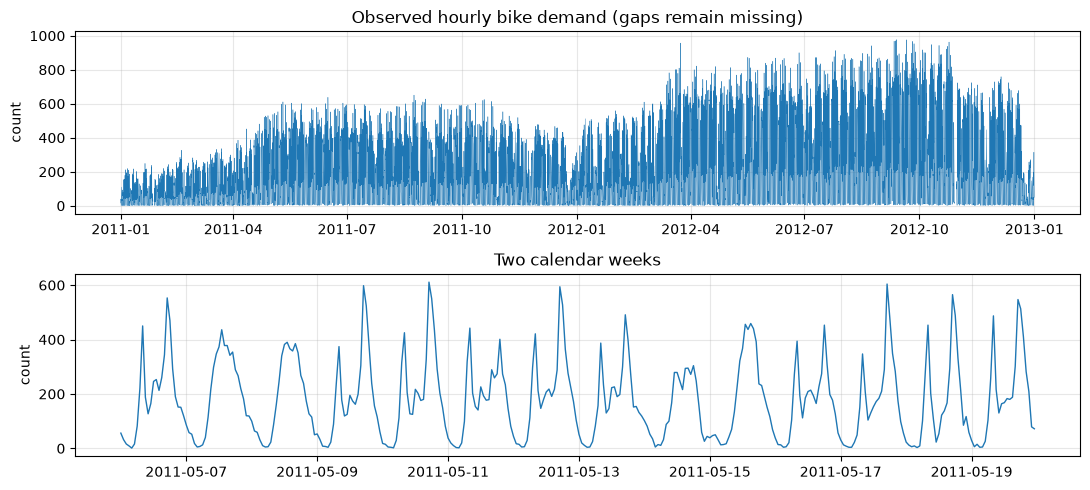

In [3]:
DATA_URL = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
cache = Path("data/bike-sharing-hour.csv")
if not cache.exists():
    with urlopen(DATA_URL, timeout=60) as response:
        payload = response.read()
    with zipfile.ZipFile(io.BytesIO(payload)) as archive:
        member = next(n for n in archive.namelist() if n.endswith("hour.csv"))
        data = archive.read(member)
    cache.parent.mkdir(parents=True, exist_ok=True)
    cache.write_bytes(data)

raw = pd.read_csv(cache)
raw["ts"] = pd.to_datetime(raw["dteday"]) + pd.to_timedelta(raw["hr"], unit="h")
assert not raw["ts"].duplicated().any(), "Resolve duplicate timestamps before modeling"
raw = raw.sort_values("ts").set_index("ts")
grid = pd.date_range(raw.index.min(), raw.index.max(), freq="h", name="ts")
df = raw.rename(columns={"cnt": "count", "hr": "hour", "yr": "year",
                         "mnth": "month", "atemp": "feel_temp", "hum": "humidity"}).reindex(grid)
# Target calendar attributes are deterministic. UCI weekday uses Sunday=0.
df["hour"] = df.index.hour
df["weekday"] = (df.index.dayofweek + 1) % 7
df["month"] = df.index.month
df["year"] = df.index.year - 2011
# These calendar flags are supplied for observed target rows; missing rows are never scored.
df["holiday_i"] = df["holiday"]
df["workingday_i"] = df["workingday"]
# UCI stores normalized weather. Convert temperatures explicitly to degrees Celsius.
df["temp"] = df["temp"] * 47 - 8
df["feel_temp"] = df["feel_temp"] * 66 - 16
df["ts"] = df.index
df = df.reset_index(drop=True)
assert df["ts"].diff().dropna().eq(pd.Timedelta(hours=1)).all()

TEST_START = df["ts"].iloc[int(len(df) * 0.8)]
print(f"{len(raw):,} observed target hours; {len(df):,} grid hours")
print(f"{df['ts'].min()} to {df['ts'].max()}")
print(f"Missing target hours: {df['count'].isna().sum()}")
print(f"Evaluation period starts: {TEST_START}")
for lag in (1, 2, 24, 168):
    print(f"Correlation at {lag:3d} calendar hours: "
          f"{df['count'].corr(df['count'].shift(lag)):.4f}")
fig, axes = plt.subplots(2, 1, figsize=(11, 5))
axes[0].plot(df["ts"], df["count"], lw=0.3)
axes[0].set(title="Observed hourly bike demand (gaps remain missing)", ylabel="count")
week = df.iloc[3000:3000 + 24 * 14]
axes[1].plot(week["ts"], week["count"], lw=1)
axes[1].set(title="Two calendar weeks", ylabel="count")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 1.2 The supervised framing

To use anything from the rest of this series, turn the series into a table. Three families of
feature:

- **Lags** — the target's own past values. `lag_1` is the previous hour, `lag_24` the same hour
  yesterday, `lag_168` the same hour last week.
- **Rolling statistics** — a mean or standard deviation over a recent window. §3.1 shows the
  one way these go catastrophically wrong.
- **Calendar and exogenous** — hour, day of week, holiday flag, and origin-available weather forecasts. Target-hour
  observed temperature is excluded from operational forecasts.

**The rule that governs all of it:** every feature must be computable from information available
**at forecast time**. That is the whole discipline, and §1.8 shows the horizon deciding what
"available" means.

In [4]:
def make_features(d, horizon=1, lags=(1, 2, 3, 24, 168), rolls=(24, 168)):
    """Target-indexed table; all demand inputs are available at t-horizon."""
    if not isinstance(horizon, (int, np.integer)) or horizon < 1:
        raise ValueError("horizon must be a positive integer")
    if any(L < horizon for L in lags):
        raise ValueError("Every requested lag must be at least the horizon")
    if not d["ts"].diff().dropna().eq(pd.Timedelta(hours=1)).all():
        raise ValueError("Build features on a complete hourly grid")
    o = d.copy()
    history = o["count"].ffill()  # causal persistence estimate for unobserved history
    for L in sorted(set(lags)):
        o[f"lag_{L}"] = history.shift(L)
    for w in rolls:
        o[f"roll_mean_{w}"] = history.shift(horizon).rolling(w).mean()
        o[f"roll_std_{w}"] = history.shift(horizon).rolling(w).std()
    o["hour_sin"] = np.sin(2 * np.pi * o["hour"] / 24)
    o["hour_cos"] = np.cos(2 * np.pi * o["hour"] / 24)
    o["dow_sin"] = np.sin(2 * np.pi * o["weekday"] / 7)
    o["dow_cos"] = np.cos(2 * np.pi * o["weekday"] / 7)
    o["origin_observed"] = o["count"].notna().shift(horizon, fill_value=False)
    return o

CALENDAR = ["hour", "weekday", "workingday_i", "holiday_i", "year", "month"]
full_feat = make_features(df)
FEATURE_COLS = CALENDAR + [c for c in full_feat if c.startswith(("lag_", "roll_"))]
# Compute shifts BEFORE removing missing targets. Preserve full_feat for time-aware operations.
feat = full_feat.dropna(subset=["count"] + FEATURE_COLS).reset_index(drop=True)
X_all, y_all = feat[FEATURE_COLS], feat["count"]
CUT = int((feat["ts"] < TEST_START).sum())
X_tr, X_te = X_all.iloc[:CUT], X_all.iloc[CUT:]
y_tr, y_te = y_all.iloc[:CUT], y_all.iloc[CUT:]
print(f"{len(feat):,} usable observed targets; {len(FEATURE_COLS)} features")
print(feat[["ts", "count", "lag_1", "lag_24", "lag_168", "origin_observed"]].head())
print("Operational feature set: calendar + past demand; no target-hour observed weather.")

def temporal_folds(timestamps, n_splits=5):
    """TimeSeriesSplit on the hourly grid, mapped back to observed eligible rows."""
    times = pd.DatetimeIndex(timestamps)
    hourly = pd.date_range(times.min(), times.max(), freq="h")
    folds = []
    for tr, te in TimeSeriesSplit(n_splits=n_splits).split(hourly):
        a = np.flatnonzero(times <= hourly[tr[-1]])
        b = np.flatnonzero((times >= hourly[te[0]]) & (times <= hourly[te[-1]]))
        if not len(a) or not len(b):
            raise ValueError("Fold contains no eligible observations")
        folds.append((a, b))
    return folds

17,218 usable observed targets; 15 features
                   ts  count  lag_1  lag_24  lag_168  origin_observed
0 2011-01-08 00:00:00   25.0   15.0    17.0     16.0             True
1 2011-01-08 01:00:00   16.0   25.0     7.0     40.0             True
2 2011-01-08 02:00:00   16.0   16.0     1.0     32.0             True
3 2011-01-08 03:00:00    7.0   16.0     1.0     13.0             True
4 2011-01-08 04:00:00    1.0    7.0     1.0      1.0             True
Operational feature set: calendar + past demand; no target-hour observed weather.


## 1.3 Random splits evaluate a different task

Compare identical model configurations with a shuffled split and a chronological split.
The evaluation samples differ: any MAE difference combines temporal information effects,
seasonal coverage, distribution shifts and sampling variation. It is not a controlled estimate
of a leakage penalty, and neither estimate guarantees future production accuracy.

Shuffled split MAE:      22.88
Chronological split MAE: 30.56
Relative score difference: +25.1%
Different test periods: this difference is not a pure leakage penalty.


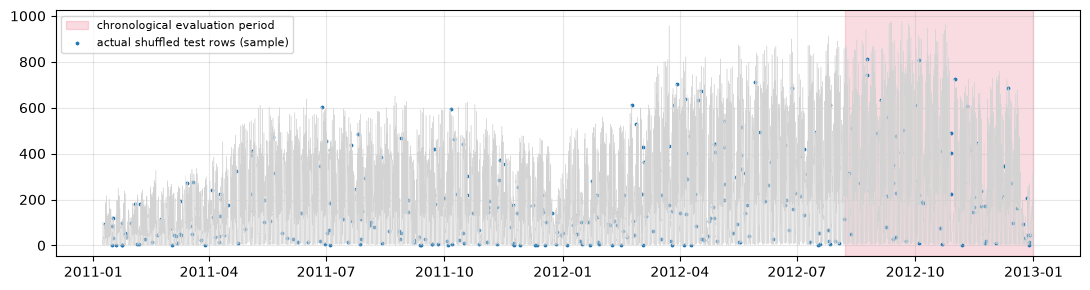

In [5]:
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)
m_random = histgb().fit(Xtr_r, ytr_r)
m_time = histgb().fit(X_tr, y_tr)
mae_random = mean_absolute_error(yte_r, m_random.predict(Xte_r))
mae_time = mean_absolute_error(y_te, m_time.predict(X_te))
print(f"Shuffled split MAE:      {mae_random:.2f}")
print(f"Chronological split MAE: {mae_time:.2f}")
print(f"Relative score difference: {1 - mae_random / mae_time:+.1%}")
print("Different test periods: this difference is not a pure leakage penalty.")
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(feat["ts"], y_all, lw=0.3, color="lightgray")
ax.axvspan(TEST_START, feat["ts"].iloc[-1], color="crimson", alpha=0.15,
           label="chronological evaluation period")
sample = yte_r.sample(min(400, len(yte_r)), random_state=RANDOM_STATE).index
ax.scatter(feat.loc[sample, "ts"], y_all.loc[sample], s=3,
           label="actual shuffled test rows (sample)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 1.4 Validating properly

`TimeSeriesSplit` can implement expanding-window rolling-origin validation; walk-forward is a
broader evaluation strategy, not a mutually exclusive alternative. Refit frequency, training
window, horizon and observation updates define the simulated deployment.

For h=1 with immediate observation availability, no extra label gap is needed. For h>1,
exclude training labels newer than the first evaluation origin (see §1.8). Unequal fold scores
can reflect seasonality, changing sample sizes and shifts; low spread is not a leakage detector.
Here the temporal fold boundaries use calendar time even when target observations are absent.

In [6]:
# Use only pre-evaluation data for cross-validation.
tscv = temporal_folds(feat["ts"].iloc[:CUT], n_splits=5)
sc_ts = cross_val_score(histgb(), X_tr, y_tr, cv=tscv,
                        scoring="neg_mean_absolute_error")
sc_kf = cross_val_score(histgb(), X_tr, y_tr,
                        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                        scoring="neg_mean_absolute_error")
for name, scores in [("temporal folds", sc_ts), ("shuffled KFold", sc_kf)]:
    print(f"{name:20s} MAE {-scores.mean():.2f}, fold std {scores.std():.2f}")
print("Temporal fold MAEs:", np.round(-sc_ts, 2))
print("Spread describes these folds; neither small nor large spread proves leakage.")

temporal folds       MAE 33.59, fold std 9.81
shuffled KFold       MAE 21.58, fold std 0.65
Temporal fold MAEs: [48.58 25.61 20.42 36.51 36.84]
Spread describes these folds; neither small nor large spread proves leakage.


 fold  train_n  test_n   MAE
    0     1469    1531 35.64
    1     3000    1540 31.31
    2     4540    1524 25.85
    3     6064    1539 22.20
    4     7603    1533 19.52
    5     9136    1535 30.41
    6    10671    1538 37.54
    7    12209    1540 32.19
Observation-weighted MAE: 29.34


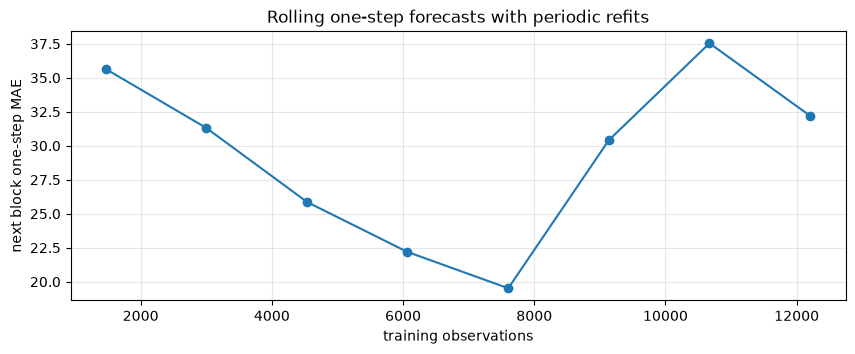

Actual earlier observations feed subsequent forecasts; the entire block is not issued at once.
Compare candidate refit schedules on common dates before choosing a production cadence.


In [7]:
def walk_forward(X, y, timestamps, model_factory, n_splits=8):
    """Rolling one-step predictions; refit once per calendar block."""
    rows = []
    for k, (tr, te) in enumerate(temporal_folds(timestamps, n_splits)):
        m = model_factory().fit(X.iloc[tr], y.iloc[tr])
        pred = m.predict(X.iloc[te])
        rows.append({"fold": k, "train_n": len(tr), "test_n": len(te),
                     "MAE": mean_absolute_error(y.iloc[te], pred)})
    return pd.DataFrame(rows)

wf = walk_forward(X_tr, y_tr, feat["ts"].iloc[:CUT], histgb)
print(wf.round(2).to_string(index=False))
print(f"Observation-weighted MAE: {np.average(wf['MAE'], weights=wf['test_n']):.2f}")
plt.plot(wf["train_n"], wf["MAE"], marker="o")
plt.xlabel("training observations"); plt.ylabel("next block one-step MAE")
plt.title("Rolling one-step forecasts with periodic refits")
plt.grid(alpha=0.3); plt.show()
print("Actual earlier observations feed subsequent forecasts; the entire block is not issued at once.")
print("Compare candidate refit schedules on common dates before choosing a production cadence.")

## 1.5 Baselines and metrics

For rolling one-hour forecasts, compare the training mean, the last available observation,
and seasonal persistence at 24 and 168 hours. Our seasonal inputs use forward-filled historical
values at missing reference hours; we report this policy rather than treating them as observed.

**MASE** divides test MAE by the mean absolute seasonal difference in the training period.
Below one means better than that *training-period scale*, not necessarily better than the
seasonal baseline on the test period. We use m=24 and only pairs with both actuals observed.
Compare test baseline MAEs directly, or report `1 - model_MAE / baseline_MAE` as test skill.

**sMAPE** is bounded but can behave poorly near zero. We define zero/zero to contribute zero
and average over all observations. RMSE emphasizes large errors more than MAE.

In [8]:
def mase(y_true, y_pred, y_train, season=24):
    """Seasonal MASE on a regular training grid; missing actual pairs are excluded."""
    a = np.asarray(y_train, dtype=float)
    if a.ndim != 1 or not isinstance(season, (int, np.integer)) or season < 1:
        raise ValueError("Expected one-dimensional history and positive integer season")
    if len(a) <= season:
        raise ValueError("Insufficient training history for this season")
    left, right = a[season:], a[:-season]
    valid = np.isfinite(left) & np.isfinite(right)
    if not valid.any():
        raise ValueError("No observed seasonal pairs")
    scale = np.mean(np.abs(left[valid] - right[valid]))
    if scale == 0:
        return np.nan  # undefined scale; do not claim skill on constant history
    return mean_absolute_error(y_true, y_pred) / scale

def smape(y_true, y_pred):
    a, p = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    if a.shape != p.shape or a.ndim != 1 or not a.size:
        raise ValueError("Inputs must be nonempty matching one-dimensional arrays")
    if not (np.isfinite(a).all() and np.isfinite(p).all()):
        raise ValueError("Score only finite observed targets and predictions")
    denom = np.abs(a) + np.abs(p)
    terms = np.divide(2 * np.abs(a - p), denom, out=np.zeros_like(a), where=denom > 0)
    return 100 * terms.mean()

y_train_grid = df.loc[df["ts"] < TEST_START, "count"].to_numpy()
BASELINES = {
    "training mean": np.full(len(y_te), y_tr.mean()),
    "last available observation": feat["lag_1"].iloc[CUT:].to_numpy(),
    "seasonal persistence 24h": feat["lag_24"].iloc[CUT:].to_numpy(),
    "seasonal persistence 168h": feat["lag_168"].iloc[CUT:].to_numpy(),
}
def metrics(y, p, history=y_train_grid):
    return {"MAE": mean_absolute_error(y, p),
            "RMSE": np.sqrt(mean_squared_error(y, p)),
            "MASE (m=24)": mase(y, p, history, 24), "sMAPE (%)": smape(y, p)}

scores = {name: metrics(y_te, p) for name, p in BASELINES.items()}
scores["HistGradientBoosting"] = metrics(y_te, m_time.predict(X_te))
print(pd.DataFrame(scores).T.round(3))
baseline_mae = scores["seasonal persistence 168h"]["MAE"]
print(f"Test skill relative to weekly persistence: "
      f"{1 - scores['HistGradientBoosting']['MAE'] / baseline_mae:+.1%}")
print("MASE uses observed training pairs; test skill uses the displayed test baseline.")

                                MAE     RMSE  MASE (m=24)  sMAPE (%)
training mean               174.626  231.746        2.891     85.865
last available observation   85.133  129.551        1.410     45.981
seasonal persistence 24h     78.957  132.799        1.307     43.438
seasonal persistence 168h    65.788  114.010        1.089     35.785
HistGradientBoosting         30.560   49.750        0.506     19.652
Test skill relative to weekly persistence: +53.5%
MASE uses observed training pairs; test skill uses the displayed test baseline.


## 1.6 Extrapolation: forests, boosting and transformed targets

A standard squared-error regression tree predicts a mean of training targets; an averaging
random forest therefore remains inside the training-target range. Gradient boosting sums
successive corrections and does **not** share this exact range bound. Nevertheless, ordinary
constant-leaf boosted trees do not extend a learned time trend as linear regression does.

The next experiment forecasts 100 steps from one fixed origin with only known calendar/time
inputs. It illustrates extrapolation on this synthetic process, not a universal model ranking.

synthetic series: y = 0.5*t + 20*sin(2*pi*t/24) + noise
train on t=0..299, forecast t=300..399

  model                                    MAE   prediction at t=399     truth
  ----------------------------------------------------------------------------
  linear regression (t as a feature)      2.51                185.25    183.24
  Ridge                                   2.52                185.34    183.24
  random forest                          29.13                131.19    183.24
  HistGradientBoosting                   31.48                130.15    183.24

  the forest's LARGEST prediction anywhere in the forecast :   163.91
  the largest value it saw during training                 :   167.73
  the actual value at the end of the forecast              :   183.24


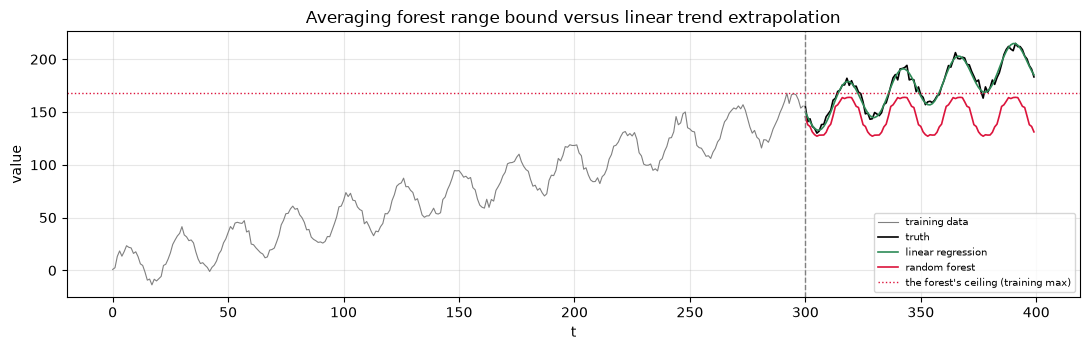


The dotted line is a hard ceiling. No amount of tuning moves it, because averaging
training targets cannot produce a value outside their range.


In [9]:
t = np.arange(400)
rng2 = np.random.default_rng(RANDOM_STATE)
synthetic = 0.5 * t + 20 * np.sin(2 * np.pi * t / 24) + rng2.normal(0, 3, len(t))

SPLIT = 300
Xs = pd.DataFrame({"t": t, "sin": np.sin(2 * np.pi * t / 24),
                   "cos": np.cos(2 * np.pi * t / 24)})
Xs_tr, Xs_te = Xs.iloc[:SPLIT], Xs.iloc[SPLIT:]
ys_tr, ys_te = synthetic[:SPLIT], synthetic[SPLIT:]

print("synthetic series: y = 0.5*t + 20*sin(2*pi*t/24) + noise")
print(f"train on t=0..{SPLIT-1}, forecast t={SPLIT}..{len(t)-1}\n")
print(f"  {'model':<34} {'MAE':>9} {'prediction at t=399':>21} {'truth':>9}")
print("  " + "-" * 76)
preds = {}
for name, m in [("linear regression (t as a feature)", LinearRegression()),
                ("Ridge", Ridge(alpha=1.0)),
                ("random forest", RandomForestRegressor(n_estimators=200,
                                                        random_state=RANDOM_STATE, n_jobs=-1)),
                ("HistGradientBoosting", HistGradientBoostingRegressor(
                    random_state=RANDOM_STATE, early_stopping=False))]:
    m.fit(Xs_tr, ys_tr)
    p = m.predict(Xs_te)
    preds[name] = p
    print(f"  {name:<34} {mean_absolute_error(ys_te, p):>9.2f} {p[-1]:>21.2f} "
          f"{synthetic[-1]:>9.2f}")

rf_p = preds["random forest"]
print(f"\n  the forest's LARGEST prediction anywhere in the forecast : {rf_p.max():>8.2f}")
print(f"  the largest value it saw during training                 : {ys_tr.max():>8.2f}")
print(f"  the actual value at the end of the forecast              : {synthetic[-1]:>8.2f}")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(t[:SPLIT], ys_tr, lw=0.8, color="gray", label="training data")
ax.plot(t[SPLIT:], ys_te, lw=1.2, color="black", label="truth")
ax.plot(t[SPLIT:], preds["linear regression (t as a feature)"], lw=1.2,
        color="seagreen", label="linear regression")
ax.plot(t[SPLIT:], rf_p, lw=1.2, color="crimson", label="random forest")
ax.axhline(ys_tr.max(), ls=":", color="crimson", lw=1,
           label="the forest's ceiling (training max)")
ax.axvline(SPLIT, color="gray", ls="--", lw=1)
ax.set(xlabel="t", ylabel="value", title="Averaging forest range bound versus linear trend extrapolation")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print()
print("The dotted line is a hard ceiling. No amount of tuning moves it, because averaging")
print("training targets cannot produce a value outside their range.")

In [10]:
def recursive_differences(model, last_level, last_difference, future_calendar):
    """No future actuals are accepted: predicted increments feed the next step."""
    level, previous = float(last_level), float(last_difference)
    predictions = []
    for row in future_calendar.itertuples(index=False):
        x = pd.DataFrame({"sin": [row.sin], "cos": [row.cos], "dlag1": [previous]})
        previous = float(model.predict(x)[0])
        level += previous
        predictions.append(level)
    return np.asarray(predictions)

# Build all learned inputs from the training period only. No synthetic starting differences.
train_diff = pd.Series(synthetic[:SPLIT]).diff()
Xd = pd.DataFrame({"sin": Xs["sin"].iloc[:SPLIT], "cos": Xs["cos"].iloc[:SPLIT],
                   "dlag1": train_diff.shift(1)})
valid = Xd.notna().all(axis=1) & train_diff.notna()
md_ = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE,
                            n_jobs=-1).fit(Xd.loc[valid], train_diff.loc[valid])
recon = recursive_differences(md_, synthetic[SPLIT - 1], train_diff.iloc[-1],
                              Xs[["sin", "cos"]].iloc[SPLIT:])
for label, p in [("forest on levels", rf_p), ("recursive forest on differences", recon),
                 ("linear trend + season", preds["linear regression (t as a feature)"])]:
    print(f"{label:40s} MAE {mean_absolute_error(ys_te, p):8.2f}, endpoint {p[-1]:8.2f}")
print("Differencing can remove a trend, but does not guarantee stationarity or better forecasts.")
print("Recursive increment errors accumulate; evaluate that accumulation rather than assuming improvement.")
print("Alternatives: fit a trend on training data and model residuals, or use an extrapolating model.")

forest on levels                         MAE    29.13, endpoint   131.19
recursive forest on differences          MAE    23.56, endpoint   228.05
linear trend + season                    MAE     2.51, endpoint   185.25
Differencing can remove a trend, but does not guarantee stationarity or better forecasts.
Recursive increment errors accumulate; evaluate that accumulation rather than assuming improvement.
Alternatives: fit a trend on training data and model residuals, or use an extrapolating model.


## 1.7 Encoding time

Hour of day is cyclical: 23:00 and 00:00 are adjacent, but as integers they are maximally far
apart. The standard advice is to encode cyclical features as $\sin$ and $\cos$ pairs.

That advice is right for some models and not others, and it is worth measuring rather than
assuming.

In [11]:
print("The problem sin/cos solves, stated exactly:\n")
for enc, f in [("raw integer", lambda h: np.array([float(h)])),
               ("sin/cos", lambda h: np.array([np.sin(2 * np.pi * h / 24),
                                               np.cos(2 * np.pi * h / 24)]))]:
    d230 = np.linalg.norm(f(23) - f(0))
    d2312 = np.linalg.norm(f(23) - f(12))
    print(f"  {enc:<14} distance(23:00, 00:00) = {d230:>6.3f}   "
          f"distance(23:00, 12:00) = {d2312:>6.3f}")

print("\n  With raw integers a LINEAR model thinks 23:00 is twice as far from midnight as")
print("  from noon, which is exactly backwards. sin/cos puts them adjacent on a circle.")
print("  A tree can partition raw hours, though encoding can still change split efficiency.")

print("\n\nMeasured, with hour as the MAIN signal (no lag features at all):\n")
dd = df.dropna(subset=["count", "workingday_i"]).copy()
dd["wd"] = dd["workingday_i"].astype(int)
c1 = int((dd["ts"] < TEST_START).sum())
yv = dd["count"]
base_cols = ["wd", "weekday"]

variants = {"no hour at all": dd[base_cols], "raw integer 0-23": dd[base_cols + ["hour"]]}
tmp = dd.copy()
tmp["hs"] = np.sin(2 * np.pi * tmp["hour"] / 24)
tmp["hc"] = np.cos(2 * np.pi * tmp["hour"] / 24)
variants["sin/cos"] = tmp[base_cols + ["hs", "hc"]]
onehot = pd.get_dummies(dd["hour"].astype("category"), prefix="h").astype(float)
variants["one-hot (24 columns)"] = pd.concat([dd[base_cols], onehot], axis=1)

print(f"  {'hour encoding':<26} {'Ridge MAE':>11} {'HistGB MAE':>12}")
print("  " + "-" * 52)
for label, Xv in variants.items():
    r = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xv.iloc[:c1], yv.iloc[:c1])
    g = HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=False).fit(Xv.iloc[:c1],
                                                                     yv.iloc[:c1])
    print(f"  {label:<26} "
          f"{mean_absolute_error(yv.iloc[c1:], r.predict(Xv.iloc[c1:])):>11.2f} "
          f"{mean_absolute_error(yv.iloc[c1:], g.predict(Xv.iloc[c1:])):>12.2f}")

print("A single harmonic limits Ridge to one daily sinusoid; one-hot or more harmonics allow richer shapes.")
print("Trees can partition raw hours, but encoding can affect split efficiency. Validate the choice.")

The problem sin/cos solves, stated exactly:

  raw integer    distance(23:00, 00:00) = 23.000   distance(23:00, 12:00) = 11.000
  sin/cos        distance(23:00, 00:00) =  0.261   distance(23:00, 12:00) =  1.983

  With raw integers a LINEAR model thinks 23:00 is twice as far from midnight as
  from noon, which is exactly backwards. sin/cos puts them adjacent on a circle.
  A tree can partition raw hours, though encoding can still change split efficiency.


Measured, with hour as the MAIN signal (no lag features at all):

  hour encoding                Ridge MAE   HistGB MAE
  ----------------------------------------------------
  no hour at all                  174.19       175.04
  raw integer 0-23                152.97       101.03
  sin/cos                         122.51       101.15
  one-hot (24 columns)            113.12       100.85
A single harmonic limits Ridge to one daily sinusoid; one-hot or more harmonics allow richer shapes.
Trees can partition raw hours, but encoding can

## 1.8 The horizon decides features AND training-label availability

For a target at t, horizon h means an origin at t-h. Demand lags must be at least h old,
and training labels must be observed by the first evaluation origin. We hold the evaluated
target timestamps fixed across h=1,6,12,24 and use no future observed weather.

Each model is fitted once at its first evaluation origin, then makes rolling h-step forecasts.
For the aligned-feature control we additionally use a common, conservative training cutoff.
Identical features, labels and deterministic fits must then produce identical scores. This is
a restriction of the information used, not evidence that greater lead time is costless.

In [12]:
def horizon_experiment(d, H, lags, train_end=None):
    b = make_features(d, horizon=H, lags=lags, rolls=())
    cols = CALENDAR + [f"lag_{L}" for L in sorted(set(lags))]
    # Common warmup across every variant, so both training start and target rows align.
    b = b.loc[b["ts"] >= d["ts"].iloc[336]].dropna(subset=["count"] + cols)
    first_origin = TEST_START - pd.Timedelta(hours=H)
    cutoff = first_origin if train_end is None else pd.Timestamp(train_end)
    if cutoff > first_origin:
        raise ValueError("Training labels extend beyond the first forecast origin")
    tr, te = b.loc[b["ts"] <= cutoff], b.loc[b["ts"] >= TEST_START]
    assert tr["ts"].max() <= te["ts"].min() - pd.Timedelta(hours=H)
    m = histgb().fit(tr[cols], tr["count"])
    p = pd.Series(m.predict(te[cols]), index=pd.DatetimeIndex(te["ts"]))
    return mean_absolute_error(te["count"], p), p

rows, target_index = [], None
for H in (1, 6, 12, 24):
    for choice, lags in [("recent", [H, H + 1, H + 23, H + 167]),
                         ("aligned", [24, 48, 168, 336])]:
        score, p = horizon_experiment(df, H, lags)
        if target_index is None:
            target_index = p.index
        assert target_index.equals(p.index), "Compare identical target timestamps"
        rows.append({"h": H, "features": choice, "MAE": score})
print(pd.DataFrame(rows).pivot(index="h", columns="features", values="MAE").round(2))
print("Model ranking and error need not be monotone in h; inspect rather than prescribe the pattern.")

common_cutoff = TEST_START - pd.Timedelta(hours=24)
control = [horizon_experiment(df, H, [24, 48, 168, 336], common_cutoff)
           for H in (1, 6, 12, 24)]
for _, p in control[1:]:
    np.testing.assert_allclose(p, control[0][1])
print("Identical-information control MAEs:", [round(v, 3) for v, _ in control])
print("Identical by construction: short horizons deliberately discard their additional recent information.")

features  aligned  recent
h                        
1           53.37   30.35
6           53.46   61.90
12          52.64   63.56
24          53.45   54.27
Model ranking and error need not be monotone in h; inspect rather than prescribe the pattern.
Identical-information control MAEs: [53.455, 53.455, 53.455, 53.455]
Identical by construction: short horizons deliberately discard their additional recent information.


***
# Part 2 - Worked example: forecasting bike demand

Forecast each next hour using calendar information and demand available at the preceding
hour's close. Data are on the complete hourly calendar grid; missing targets are not scored.
Persistence-filled history is allowed as an explicitly estimated feature, never as ground truth.
The estimator stays fixed throughout the evaluation period, while its lag inputs update.

## 2.1 Decide the task before touching the data

Three decisions come first, and all three change the feature set:

In [13]:
print("Horizon: one hour; origin observation assumed immediately available")
print("Frequency: complete hourly calendar grid; missing actuals retained as NaN")
print("Feature policy: forward-filled past demand; known target calendar; no future weather")
print(f"Missing target hours: {df['count'].isna().sum()}")
print(f"Duplicate timestamps: {df['ts'].duplicated().sum()}")
print(f"Train: {feat['ts'].iloc[0]} to {feat['ts'].iloc[CUT-1]} ({CUT:,} targets)")
print(f"Test:  {feat['ts'].iloc[CUT]} to {feat['ts'].iloc[-1]} ({len(y_te):,} targets)")
stale = ~feat["origin_observed"].iloc[CUT:]
print(f"Test forecasts whose origin demand was missing: {stale.sum()} ({stale.mean():.1%})")
assert (feat["ts"].iloc[:CUT] < TEST_START).all()
assert (feat["ts"].iloc[CUT:] >= TEST_START).all()

Horizon: one hour; origin observation assumed immediately available
Frequency: complete hourly calendar grid; missing actuals retained as NaN
Feature policy: forward-filled past demand; known target calendar; no future weather
Missing target hours: 165
Duplicate timestamps: 0
Train: 2011-01-08 00:00:00 to 2012-08-07 18:00:00 (13,749 targets)
Test:  2012-08-07 19:00:00 to 2012-12-31 23:00:00 (3,469 targets)
Test forecasts whose origin demand was missing: 5 (0.1%)


## 2.2 Look at the structure you have to model

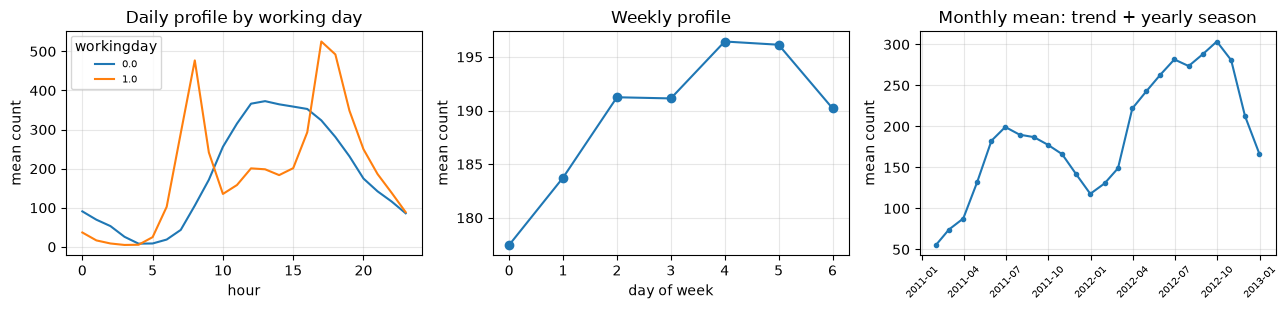

mean rentals, year 1 : 143.8
mean rentals, year 2 : 234.7   (+63.2%)
These are descriptive full-series plots. Use training-only summaries for feature selection.
A higher test mean does not establish that all test targets exceed the training range.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

hourly = df.groupby(["hour", "workingday_i"])["count"].mean().unstack()
hourly.plot(ax=axes[0], lw=1.5)
axes[0].set(title="Daily profile by working day", xlabel="hour", ylabel="mean count")
axes[0].legend(title="workingday", fontsize=7)

df.groupby("weekday")["count"].mean().plot(ax=axes[1], marker="o")
axes[1].set(title="Weekly profile", xlabel="day of week", ylabel="mean count")

monthly = df.set_index("ts")["count"].resample("ME").mean()
axes[2].plot(monthly.index, monthly.to_numpy(), marker="o", ms=3)
axes[2].set(title="Monthly mean: trend + yearly season", ylabel="mean count")
axes[2].tick_params(axis="x", rotation=45, labelsize=7)

for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

y1 = df[df["year"] == 0]["count"].mean()
y2 = df[df["year"] == 1]["count"].mean()
print(f"mean rentals, year 1 : {y1:.1f}")
print(f"mean rentals, year 2 : {y2:.1f}   ({(y2/y1 - 1):+.1%})")
print("These are descriptive full-series plots. Use training-only summaries for feature selection.")
print("A higher test mean does not establish that all test targets exceed the training range.")

## 2.3 Baselines first, then the model

In [15]:
results = {name: p.copy() for name, p in BASELINES.items()}
fitted = {}
for name, model in [
    ("Ridge (scaled)", make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
    ("random forest", RandomForestRegressor(n_estimators=200,
                                            random_state=RANDOM_STATE, n_jobs=-1)),
    ("HistGradientBoosting", histgb()),
]:
    fitted[name] = model.fit(X_tr, y_tr)
    results[name] = model.predict(X_te)
table = pd.DataFrame({name: metrics(y_te, p) for name, p in results.items()}).T
table["skill vs weekly (%)"] = 100 * (1 - table["MAE"] / baseline_mae)
print(table.round(3))
print("All rows score the same observed target hours with the same origin availability.")

                                MAE     RMSE  MASE (m=24)  sMAPE (%)  skill vs weekly (%)
training mean               174.626  231.746        2.891     85.865             -165.439
last available observation   85.133  129.551        1.410     45.981              -29.405
seasonal persistence 24h     78.957  132.799        1.307     43.438              -20.019
seasonal persistence 168h    65.788  114.010        1.089     35.785                0.000
Ridge (scaled)               51.981   78.139        0.861     34.855               20.987
random forest                31.845   52.996        0.527     19.411               51.594
HistGradientBoosting         30.560   49.750        0.506     19.652               53.548
All rows score the same observed target hours with the same origin availability.


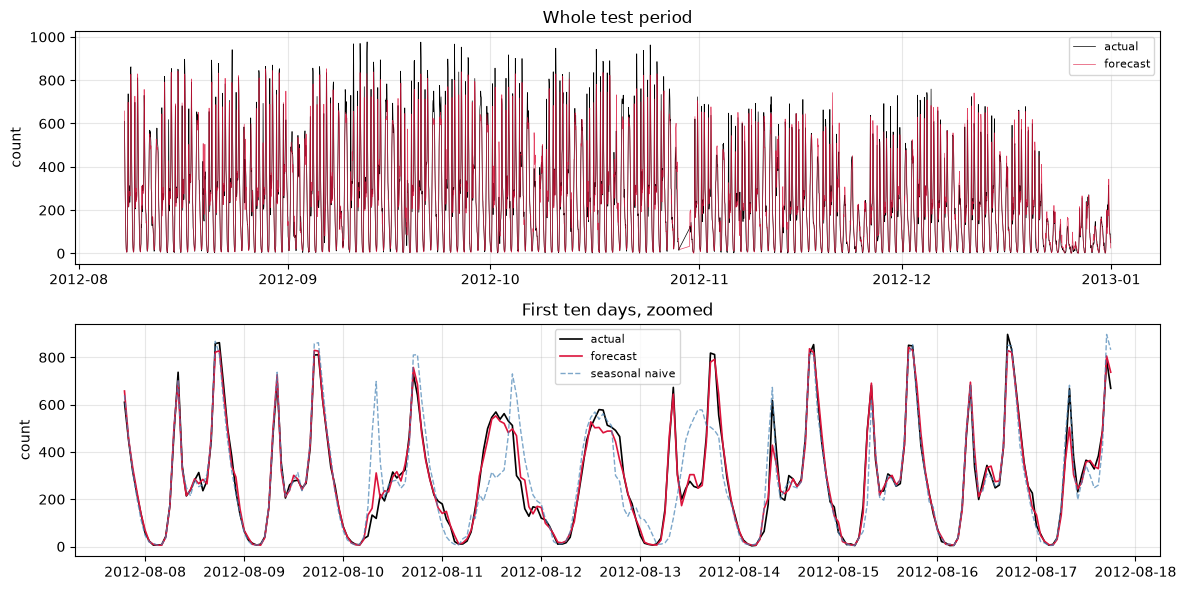

residual mean -0.53, std 49.75
as a share of the mean actual: -0.21%
share of hours the model UNDER-predicts: 47.8%
Positive mean forecast error means average underprediction; it does not identify the cause.


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(feat["ts"].iloc[CUT:], y_te, lw=0.5, color="black", label="actual")
axes[0].plot(feat["ts"].iloc[CUT:], results["HistGradientBoosting"], lw=0.5,
             color="crimson", alpha=0.8, label="forecast")
axes[0].set(title="Whole test period", ylabel="count")
axes[0].legend(fontsize=8)

n_zoom = int((feat["ts"].iloc[CUT:] < TEST_START + pd.Timedelta(days=10)).sum())
sl = slice(CUT, CUT + n_zoom)
axes[1].plot(feat["ts"].iloc[sl], y_all.iloc[sl], lw=1.2, color="black", label="actual")
axes[1].plot(feat["ts"].iloc[sl], results["HistGradientBoosting"][:n_zoom], lw=1.2,
             color="crimson", label="forecast")
axes[1].plot(feat["ts"].iloc[sl], results["seasonal persistence 24h"][:n_zoom], lw=1,
             color="steelblue", ls="--", alpha=0.7, label="seasonal naive")
axes[1].set(title="First ten days, zoomed", ylabel="count")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

resid = y_te.to_numpy() - results["HistGradientBoosting"]
print(f"residual mean {resid.mean():+.2f}, std {resid.std():.2f}")
print(f"as a share of the mean actual: {resid.mean() / y_te.mean():+.2%}")
print(f"share of hours the model UNDER-predicts: {(resid > 0).mean():.1%}")
print("Positive mean forecast error means average underprediction; it does not identify the cause.")

## 2.4 Diagnose the errors — where and when is it wrong?

An aggregate MAE hides everything that matters operationally. Break it down.

MAE by hour of day (worst six):
  17h=71  08h=59  18h=59  09h=44  16h=44  13h=42

MAE by hour of day (best six):
  06h=17  01h=12  02h=7  05h=7  03h=5  04h=3

MAE and bias by month of the test period:
          MAE  bias  mean_actual
month                           
2012-08  28.8  -1.3        288.6
2012-09  36.2   6.9        303.6
2012-10  39.0   0.1        280.8
2012-11  27.3  -3.2        212.6
2012-12  21.5  -5.1        166.7


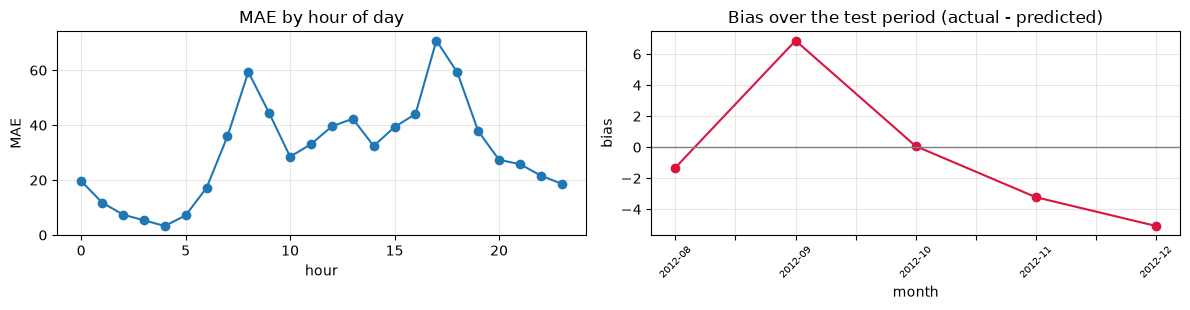

Months with positive bias: 2 of 5
Check magnitude, changing demand levels and model inputs before attributing bias to a trend.
Inspect operational cost by hour; percentage errors can become unstable at low demand.


In [17]:
diag = pd.DataFrame({
    "ts": feat["ts"].iloc[CUT:].to_numpy(),
    "actual": y_te.to_numpy(),
    "pred": results["HistGradientBoosting"],
})
diag["err"] = diag["actual"] - diag["pred"]
diag["abs_err"] = diag["err"].abs()
diag["hour"] = diag["ts"].dt.hour
diag["month"] = diag["ts"].dt.to_period("M").astype(str)

print("MAE by hour of day (worst six):")
by_hour = diag.groupby("hour")["abs_err"].mean().sort_values(ascending=False)
print("  " + "  ".join(f"{h:02d}h={v:.0f}" for h, v in by_hour.head(6).items()))
print("\nMAE by hour of day (best six):")
print("  " + "  ".join(f"{h:02d}h={v:.0f}" for h, v in by_hour.tail(6).items()))

print("\nMAE and bias by month of the test period:")
by_month = diag.groupby("month").agg(MAE=("abs_err", "mean"), bias=("err", "mean"),
                                     mean_actual=("actual", "mean"))
print(by_month.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
diag.groupby("hour")["abs_err"].mean().plot(ax=axes[0], marker="o")
axes[0].set(title="MAE by hour of day", xlabel="hour", ylabel="MAE")
by_month["bias"].plot(ax=axes[1], marker="o", color="crimson")
axes[1].axhline(0, color="gray", lw=1)
axes[1].set(title="Bias over the test period (actual - predicted)", ylabel="bias")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print("Months with positive bias:", int((by_month["bias"] > 0).sum()), "of", len(by_month))
print("Check magnitude, changing demand levels and model inputs before attributing bias to a trend.")
print("Inspect operational cost by hour; percentage errors can become unstable at low demand.")

In [18]:
print("Calendar and lag ablation, with identical target rows:")
rows = []
for label, cols in [("calendar", CALENDAR),
                    ("calendar + daily/weekly lag", CALENDAR + ["lag_24", "lag_168"]),
                    ("calendar + recent/daily/weekly lag", CALENDAR + ["lag_1", "lag_24", "lag_168"])]:
    m = histgb().fit(feat[cols].iloc[:CUT], y_tr)
    p = m.predict(feat[cols].iloc[CUT:])
    rows.append({"features": label, "MAE": mean_absolute_error(y_te, p),
                 "bias": np.mean(y_te.to_numpy() - p), "max prediction": p.max()})
print(pd.DataFrame(rows).round(2).to_string(index=False))
print(f"Training target range: {y_tr.min():.0f} to {y_tr.max():.0f}")
print(f"Evaluation target range: {y_te.min():.0f} to {y_te.max():.0f}")
print("Lags can help track recent demand. They do not guarantee extrapolation outside training support.")

Calendar and lag ablation, with identical target rows:
                          features   MAE   bias  max prediction
                          calendar 67.41 -22.50          825.37
       calendar + daily/weekly lag 54.21   1.65          848.46
calendar + recent/daily/weekly lag 30.01   1.81          847.40
Training target range: 1 to 957
Evaluation target range: 1 to 977
Lags can help track recent demand. They do not guarantee extrapolation outside training support.


***
# Part 3 - The traps

Three things that produce a good-looking number and a broken forecast.

## 3.1 Rolling-window leakage

Rolling means and standard deviations are among the most useful forecasting features. They are
also the easiest place to leak, because pandas will happily compute a window that includes the
current row — or, worse, future rows.

The correct construction is **shift first, then roll**.

In [19]:
d3 = df.copy()
cnt = d3["count"].ffill()
d3["roll_ok"] = cnt.shift(1).rolling(24).mean()
d3["roll_includes_now"] = cnt.rolling(24).mean()
d3["roll_centred"] = cnt.rolling(24, center=True).mean()
base3 = CALENDAR
variants = ["roll_ok", "roll_includes_now", "roll_centred"]
dd3 = d3.dropna(subset=["count"] + base3 + variants)
tr3, te3 = dd3["ts"] < TEST_START, dd3["ts"] >= TEST_START
for feature in variants:
    print(f"{feature:25s} correlation {dd3[feature].corr(dd3['count']):.4f}")
for label, cols in [("calendar", base3)] + [(f, base3 + [f]) for f in variants]:
    m = histgb().fit(dd3.loc[tr3, cols], dd3.loc[tr3, "count"])
    score = mean_absolute_error(dd3.loc[te3, "count"], m.predict(dd3.loc[te3, cols]))
    print(f"{label:25s} MAE {score:.2f}")
print("The unshifted and centered windows are invalid regardless of whether this model benefits.")
print("Correlation cannot establish availability; test construction against the forecast origin.")

roll_ok                   correlation 0.3993
roll_includes_now         correlation 0.4165
roll_centred              correlation 0.4356
calendar                  MAE 68.60
roll_ok                   MAE 44.41
roll_includes_now         MAE 40.49
roll_centred              MAE 33.00
The unshifted and centered windows are invalid regardless of whether this model benefits.
Correlation cannot establish availability; test construction against the forecast origin.


## 3.2 A fair classical comparison

Compare SARIMAX, additive seasonal exponential smoothing and histogram boosting on the same
seven calendar days, using rolling one-hour forecasts and the same 1,500-hour training window.
Both classical models see the same causally filled history used in ML lag features. ML uses
only demand features here, not calendar or weather, to keep the information sources comparable.
Its first 168 hours are feature warmup; unobserved training targets are excluded from its fit.

Parameters are fitted once. SARIMAX updates its filtered state with each new observation using
`append(refit=False)`; ETS applies the fitted smoothing parameters as observations arrive.
Neither observes the current target before predicting it. Missing actuals are not scored, and
the persistence estimate is used for the state update consistently with the feature policy.
This short demonstration is not sufficient to establish a general winner.

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

series = df.set_index("ts")["count"].astype(float).asfreq("h")
history = series.ffill()
window = history.loc[history.index < TEST_START].iloc[-1500:]
eval_index = history.loc[(history.index >= TEST_START) &
                         (history.index < TEST_START + pd.Timedelta(days=7))].index

t0 = time.time()
sar = SARIMAX(window, order=(2, 0, 1), seasonal_order=(1, 0, 1, 24),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
if not sar.mle_retvals.get("converged", False):
    raise RuntimeError("SARIMAX did not converge; inspect the fit before reporting its score")
sar_fit_seconds = time.time() - t0
ets = ExponentialSmoothing(window, trend=None, seasonal="add", seasonal_periods=24).fit()
params = ets.params
alpha, gamma = params["smoothing_level"], params["smoothing_seasonal"]
level = float(np.asarray(ets.level)[-1])
seasons = list(np.asarray(ets.season)[-24:])

demand_cols = [c for c in FEATURE_COLS if c.startswith(("lag_", "roll_"))]
indexed = make_features(df.loc[df["ts"] >= window.index[0]].copy()).set_index("ts")
ml_train = indexed.loc[window.index].dropna(subset=["count"] + demand_cols)
ml = histgb().fit(ml_train[demand_cols], ml_train["count"])
sar_predictions, ets_predictions = [], []
for stamp in eval_index:
    sar_predictions.append(float(sar.forecast(1).iloc[0]))
    season = seasons.pop(0)
    ets_predictions.append(level + season)
    observed_or_persisted = float(history.loc[stamp])
    old_level = level
    level = alpha * (observed_or_persisted - season) + (1 - alpha) * old_level
    seasons.append(gamma * (observed_or_persisted - old_level) + (1 - gamma) * season)
    sar = sar.append(pd.Series([observed_or_persisted], name=window.name,
                               index=pd.DatetimeIndex([stamp], freq="h")),
                     refit=False)

comparison = pd.DataFrame({"actual": series.loc[eval_index],
    "SARIMAX rolling 1h": sar_predictions, "ETS rolling 1h": ets_predictions,
    "HistGB rolling 1h": ml.predict(indexed.loc[eval_index, demand_cols]),
    "seasonal persistence 24h": history.shift(24).loc[eval_index]})
comparison = comparison.dropna(subset=["actual"])
print(f"Same {len(comparison)} observed targets, {eval_index.min()} to {eval_index.max()}")
for name in comparison.columns.drop("actual"):
    print(f"{name:30s} MAE {mean_absolute_error(comparison['actual'], comparison[name]):.2f}")
print(f"SARIMAX initial fit: {sar_fit_seconds:.1f}s; state updates do not refit parameters.")

Same 168 observed targets, 2012-08-07 19:00:00 to 2012-08-14 18:00:00
SARIMAX rolling 1h             MAE 46.70
ETS rolling 1h                 MAE 55.21
HistGB rolling 1h              MAE 32.42
seasonal persistence 24h       MAE 72.98
SARIMAX initial fit: 8.4s; state updates do not refit parameters.


## 3.3 What breaks in production

Forecasting models degrade in ways that are specific to the problem shape.

In [21]:
print("A. Forecast error as a fixed model ages (rolling one-step forecasts)")
fixed_time = df["ts"].iloc[int(len(df) * 0.6)]
past = feat["ts"] < fixed_time
m_fixed = histgb().fit(X_all.loc[past], y_all.loc[past])
rows = []
for k in range(6):
    lo, hi = fixed_time + pd.Timedelta(weeks=4*k), fixed_time + pd.Timedelta(weeks=4*(k+1))
    mask = (feat["ts"] >= lo) & (feat["ts"] < hi)
    if not mask.any():
        continue
    p, act = m_fixed.predict(X_all.loc[mask]), y_all.loc[mask].to_numpy()
    rows.append({"weeks since fit": f"{4*k}-{4*(k+1)}", "MAE": mean_absolute_error(act, p),
                 "bias": np.mean(act-p), "mean actual": act.mean()})
print(pd.DataFrame(rows).round(2).to_string(index=False))
print("Neither MAE nor bias is required to grow monotonically. Seasonality and shifts confound age.")
print("Choose a refit schedule by comparing candidate schedules on common earlier validation dates.")

print("\nB. Weather availability: deployable inputs versus a deliberately unavailable benchmark")
weather_cols = ["temp", "feel_temp", "humidity", "windspeed"]
w = make_features(df)
for c in weather_cols:
    w[f"{c}_past"] = w[c].ffill().shift(1)
cols_past = [f"{c}_past" for c in weather_cols]
w = w.dropna(subset=["count"] + FEATURE_COLS + weather_cols + cols_past)
trw, tew = w["ts"] < TEST_START, w["ts"] >= TEST_START
for label, extras in [("no weather (operational)", []),
                       ("past observed weather (operational)", cols_past),
                       ("target-hour actual weather (unavailable)", weather_cols)]:
    cols = FEATURE_COLS + extras
    m = histgb().fit(w.loc[trw, cols], w.loc[trw, "count"])
    print(f"{label:45s} MAE {mean_absolute_error(w.loc[tew, 'count'], m.predict(w.loc[tew, cols])):.2f}")
print("The unavailable row is an illustration, not a production estimate or a guaranteed bound.")
print("To evaluate weather forecasts, use historical issue-time records at the actual lead time.")

A. Forecast error as a fixed model ages (rolling one-step forecasts)
weeks since fit   MAE  bias  mean actual
            0-4 42.27  8.73       250.81
            4-8 42.23 10.57       242.36
           8-12 55.86 25.80       268.28
          12-16 49.16 22.93       278.87
          16-20 54.73 18.59       275.54
          20-24 55.35 26.88       285.66
Neither MAE nor bias is required to grow monotonically. Seasonality and shifts confound age.
Choose a refit schedule by comparing candidate schedules on common earlier validation dates.

B. Weather availability: deployable inputs versus a deliberately unavailable benchmark
no weather (operational)                      MAE 30.56
past observed weather (operational)           MAE 30.19
target-hour actual weather (unavailable)      MAE 30.00
The unavailable row is an illustration, not a production estimate or a guaranteed bound.
To evaluate weather forecasts, use historical issue-time records at the actual lead time.


***
# Part 4 - Tough questions

### Q1. Can you use `train_test_split` on a time series?

<details><summary>Answer</summary>

`train_test_split(shuffle=False)` can implement a chronological holdout. Its default shuffled
split usually does not simulate deployment into the future: training can include dates later
than an evaluation target. §1.3 compares the two protocols, but the difference also reflects
their different test samples. It is not an isolated leakage penalty or guaranteed production gap.

Use chronological evaluation for this forecasting task. Standard K-fold can be valid under
specific autoregressive/error assumptions; see Bergmeir, Hyndman & Koo in Part 6. High lag
correlation and low fold-score variance alone do not prove leakage.

</details>

### Q2. How do you turn a time series into supervised learning?

<details><summary>Answer</summary>

For target y_t and origin t-h, use demand lags at least h old, rolling summaries of history
shifted by h, and calendar attributes known in advance. Historical weather forecasts need
issue timestamps; target-hour observed weather is unavailable. Respect reporting delays too.

Build lags on the regular time grid BEFORE removing unobserved targets. Here missing history
is forward-filled as a persistence estimate, missing actuals remain unscored, and the longest
lag/window determines warmup. Fitting an imputer or scaler on future data is not permitted.

</details>

### Q3. Which baselines and metrics should be reported?

<details><summary>Answer</summary>

Compare last-observation, daily/weekly seasonal persistence, and a training mean on the same
target timestamps, forecast origins and missing-history policy. At multi-step horizons, a
baseline must not quietly update from observations unavailable at its origin.

MASE divides test MAE by a TRAINING seasonal-difference scale. MASE < 1 does not guarantee
beating a test seasonal baseline. Report the baseline's actual test MAE and relative skill
`1 - model_MAE / baseline_MAE`. Our m=24 MASE excludes missing training pairs and returns NaN
for a zero scale. RMSE emphasizes large misses; MAE is in target units. sMAPE here assigns
zero/zero a zero contribution and averages over all targets; it can still be awkward near zero.

</details>

### Q4. Why do trees struggle with a trending series?

<details><summary>Answer</summary>

An ordinary squared-error regression tree predicts training-target leaf means; averaging
random forests cannot leave the training-target range. Gradient boosting sums corrections
and does not share that exact bound. Constant-leaf trees still do not extend a trend along an
unseen time coordinate as a linear trend model would.

Try a training-fitted trend plus residual model, differencing, or an extrapolating component.
Differencing does not guarantee stationarity or improved accuracy. §1.6 now forecasts differences
recursively, feeding back predicted increments without future actuals; errors can accumulate.
Lag features often help track recent demand, but do not guarantee prediction beyond training
support. Compare alternatives using the intended horizon rather than assuming one is best.

</details>

### Q5. Should you use sin/cos for hour of day?

<details><summary>Answer</summary>

Cyclic encoding removes the artificial distance between 23:00 and 00:00, which helps some
distance-based models. In a linear model, a single sin/cos pair can express only one harmonic;
one-hot encoding, higher harmonics, periodic splines and working-day interactions can represent
richer daily profiles. Trees can partition raw integer hours, but encoding affects split
efficiency and regularization. §1.7 compares options; its ranking is dataset-specific.

</details>

### Q6. What changes at horizon 24 instead of horizon 1?

<details><summary>Answer</summary>

For target t, the origin moves from t-1 to t-24. Lags 1 through 23 become unavailable,
weather forecasts have different lead times, and training labels must stop at or before t-24.
§1.8 uses common target dates and enforces that boundary. Its identical-information control
discards short-horizon information and must give identical predictions; it does not show that
horizon never matters. Seasonal alignment can help, and measured errors need not be monotone.

**Direct:** fit a separate model for each horizon using inputs available at the origin.
**Recursive:** repeatedly apply a one-step model, rebuilding features with predicted values.
Recursive errors can propagate, but neither strategy always wins. Evaluate many forecast
origins, not a single trajectory, when comparing their error by horizon.

</details>

### Q7. How do TimeSeriesSplit and walk-forward relate?

<details><summary>Answer</summary>

TimeSeriesSplit supplies ordered expanding-window index splits and can implement walk-forward
(rolling-origin) evaluation. The terms do not define disjoint methods. Specify training-window
length, refit frequency, lead time, label gap and whether observations update between forecasts.

§1.4 fits once per block and predicts rolling one-step targets with updated actual history.
Calendar-grid fold boundaries keep durations comparable despite missing targets. Use earlier
folds to select features, hyperparameters and retraining cadence; reserve a final untouched
period for a final estimate. Compare sliding and expanding windows on common dates.

</details>

### Q8. What is stationarity, and do you need it?

<details><summary>Answer</summary>

Weak stationarity means a constant mean and covariance depending on lag rather than absolute
time, with finite variance. Strict stationarity concerns all joint distributions. ARIMA models
allow integrated nonstationary levels while modeling a stationary ARMA component after suitable
differencing; seasonal models add seasonal structure. Classical models as a family do not all
require stationary levels.

Supervised ML does not formally require stationarity, but changes in the input distribution or
target relationship can hurt forecasts. Plot the series and use ADF/KPSS with their assumptions
and null hypotheses in mind. Differencing may remove some trends; log transforms may stabilize
multiplicative variation. Neither is a universal fix, and excessive differencing can hurt.

</details>

### Q9. A rolling feature improved MAE. Is it valid?

<details><summary>Answer</summary>

Check its availability. For demand-history features at horizon h, a causal trailing window on
`history.shift(h)` excludes unavailable targets. Centered or unshifted windows can expose the
answer even with a chronological split. A leak is invalid whether or not it improves one score.

Perturb every target AFTER the origin and rebuild the complete pipeline: features at the chosen
target must not change. This includes unavailable past lags for h>1 as well as the target and
future values. Also audit training-label cutoffs, preprocessing fits and exogenous release times.
Correlation is only a heuristic and cannot certify absence of leakage.

</details>

### Q10. Do you need classical models if you have gradient boosting?

<details><summary>Answer</summary>

They are useful baselines. Short series, smooth structure, covariate availability, pooled learning
and operational constraints all affect performance; no family always wins. Thousands of related
series can favor a global ML model as well as automated per-series statistical methods.

§3.2 evaluates classical and ML models on the same rolling one-hour targets with the same
history window and no future weather. State updates are not parameter refits. A fixed-origin
multi-step comparison would instead require both families to forecast without future observations.

M4's winner combined exponential smoothing and a neural network. M5 Accuracy's winning approach
used LightGBM models; do not generalize M4's hybrid result into a claim that pure ML cannot win.
Classical intervals and learned quantiles both require empirical evaluation of calibration.

</details>

### Q11. How should prediction intervals be evaluated?

<details><summary>Answer</summary>

Options include quantile regression, model-based forecast distributions, and conformal calibration.
Fit quantile models at 0.05/0.5/0.95, check for crossing quantiles and evaluate a nominal 90%
interval's coverage together with width and appropriate quantile/interval scores. Overcoverage
can mean excessive width, but does not automatically make an interval useless. Coverage estimates
have sampling uncertainty and depend on the evaluated population.

Intervals often widen at longer horizons, but need not widen strictly at every step: seasonal
naive intervals, for example, can have the same width within a season. Validate coverage and
width by horizon rather than diagnosing constant width alone as a bug.

Split conformal uses a separate chronological calibration block and, under exchangeability,
the finite-sample residual order statistic at rank ceil((n+1)*(1-alpha)), with the appropriate
infinite endpoint if that rank exceeds n. Ordinary exchangeability guarantees do not automatically
apply to time series. Use a suitable temporal method and report empirical future coverage.

M5 Accuracy used WRMSSE for point forecasts; M5 Uncertainty used weighted scaled pinball loss
(WSPL) for quantile forecasts.

</details>

### Q12. A forecast is consistently too low. What should you investigate?

<details><summary>Answer</summary>

Positive mean error (actual minus prediction) indicates average underprediction, not its cause.
Investigate level/trend shifts, missing or delayed features, demand outside training support,
changed covariate relationships, and retraining cadence. Separate changes in error magnitude
from changes in demand level. Plot error by date, hour and segment alongside input distributions.

§2.4 and §3.3 calculate the patterns rather than asserting that every month is positive or that
bias grows monotonically. Compare candidate retraining schedules on the same validation periods;
an aging-model plot alone does not determine an optimal schedule. Monitor missing-history and
stale-feature rates as well as MAE and signed error.

</details>

***
## Coding challenges

### Challenge 1 — direct and recursive multi-step forecasts

1. Implement `recursive_forecast(model, history, future_calendar, n_steps)` using no future
   observed weather or demand. Rebuild each lag/window with earlier predictions.
2. Fit direct models for h=1...48. Each training label must be available at the fit origin.
3. Evaluate both strategies at many common origins with 48-hour trajectories. Keep missing
   actuals out of the loss while retaining the hourly grid for feature construction.
4. Plot mean absolute error by horizon and compare seasonal persistence, extending its historical
   seasonal profile without reading unavailable actuals. Is there a crossover? Do not assume one.
5. Repeat with seasonally aligned lags and explain what information each model uses.

### Challenge 2 — test availability, not just correlation

1. Plant an unshifted rolling mean, centered mean, unshifted expanding mean and full-series
   target encoding. Compare scores, without assuming every leak improves every fitted model.
2. For a target t and horizon h, alter ALL target values after t-h and rebuild features. The
   legal feature row at t must remain identical. Include a feature depending only on t+1 so
   that perturbing y_t alone would miss it.
3. Repeat for several targets, horizons and missing-history patterns. Check preprocessing and
   training-label cutoffs separately. High correlation is not proof of leakage or its absence.

### Challenge 3 — intervals with measured coverage

1. Fit `HistGradientBoostingRegressor(loss="quantile", quantile=q, early_stopping=False)` for
   q=0.05,0.5,0.95. Reserve chronological training, calibration and final evaluation blocks.
2. Measure coverage and width overall, by hour and by horizon; check and handle quantile crossing.
   A nominal 90% interval need not achieve exactly 90% in a finite dependent sample.
3. Compare h=1,6,24 on common origins. Investigate width differences without requiring strict
   monotonicity at every horizon.
4. Compare a calibrated absolute-residual interval, using the finite-sample conformal quantile
   described in Q11. Discuss temporal dependence and evaluate future coverage empirically.

***
# Part 5 - Five datasets to practise on

| # | Dataset | Shape | The skill it forces | Difficulty |
|---|---|---|---|---|
| 1 | **Airline passengers** | 144 months | Trend + multiplicative seasonality, tiny data | ★☆☆☆☆ |
| 2 | **Bike sharing** | 17,379 hours | Used in Parts 2–3; go further | ★★☆☆☆ |
| 3 | **Household electricity** | Minute-level; aggregate to hours | Multiple seasonalities at once | ★★★☆☆ |
| 4 | **M5 / retail sales** | 30k series | **Many series, intermittent demand, hierarchy** | ★★★★★ |
| 5 | **Your own metric** | — | The one where you know what a good forecast is worth | ★★★★☆ |

AirPassengers: 144 monthly observations


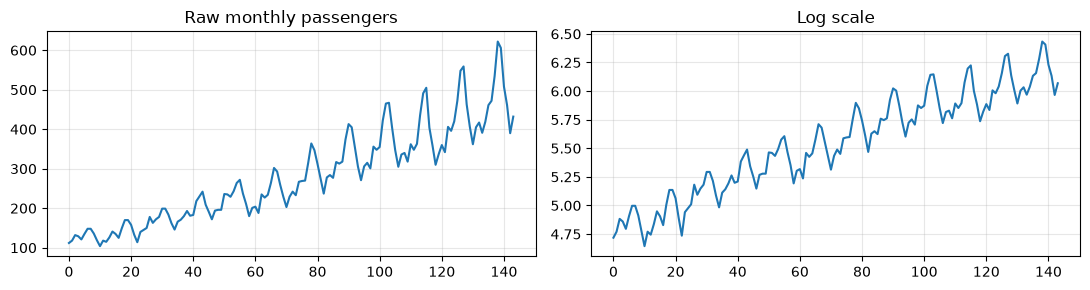

A log transform turns multiplicative components into additive components.
Inspect detrended seasonal variation; comparing coefficients of variation after log is not a test.


In [22]:
# AirPassengers is downloaded from R datasets on first use; it is not bundled with statsmodels.
air_cache = Path("data/AirPassengers.csv")
if not air_cache.exists():
    with urlopen("https://vincentarelbundock.github.io/Rdatasets/csv/datasets/AirPassengers.csv",
                 timeout=60) as response:
        air_cache.parent.mkdir(parents=True, exist_ok=True)
        air_cache.write_bytes(response.read())
air = pd.read_csv(air_cache)[["time", "value"]].rename(columns={"value": "passengers"})
print(f"AirPassengers: {len(air)} monthly observations")
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(air["passengers"]); axes[0].set(title="Raw monthly passengers")
axes[1].plot(np.log(air["passengers"])); axes[1].set(title="Log scale")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()
print("A log transform turns multiplicative components into additive components.")
print("Inspect detrended seasonal variation; comparing coefficients of variation after log is not a test.")

### 1. Airline passengers — trend, seasonality, and only 144 points

```python
import statsmodels.api as sm
air = sm.datasets.get_rdataset("AirPassengers").data
```

The canonical teaching series: monthly totals 1949–1960, with a clear trend and a seasonal
amplitude that grows with the level.

1. Fit ETS and SARIMA. With 144 points, classical models are useful candidates. Compare a
   gradient-boosted lag model using the same origins, horizon and available inputs.
2. Apply a log transform first. Does it help both families equally?
3. Reproduce §1.6 here: does a tree on the raw series get stuck below the trend?
4. Decompose into trend / seasonal / residual with `seasonal_decompose` and `STL`. Which handles
   the growing amplitude better, and why?
5. Hold out the last 24 months and forecast. Plot prediction intervals (Q11) and check coverage.

***

### 2. Bike sharing — go further than Part 2

Used throughout Parts 2 and 3.

1. Build the **direct multi-horizon** models from Challenge 1 and plot MAE against horizon.
2. Reproduce §1.6's trend problem on the real data: train only on year 1, test on year 2, and
   compare a tree against a tree on the *differenced* series.
3. Add interaction features — `hour × workingday` explicitly — and see whether the gradient
   boosting already captured them.
4. Split the target into `casual` and `registered` riders from the UCI data already loaded.
   They have very different daily profiles; does forecasting them separately and summing beat
   forecasting the total?
5. Extend §3.3 using archived weather forecasts with issuance times and lead times.
   Compare them with past-weather inputs on identical targets.

***

### 3. Electricity load — multiple seasonalities at once

Use the [UCI household power consumption dataset](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption),
aggregate to an hourly grid and document missing intervals. `electricity-normalized` is a
classification benchmark and is not a ready-made hourly load forecasting target.

Load data has a daily cycle, a weekly cycle *and* a yearly cycle, plus holiday effects — the
regime where a single seasonal period is not enough.

1. Build lag features at 24 and 168 hours, plus calendar-aligned annual features. Which matter most?
2. Fourier terms are the standard way to handle several seasonalities in one linear model: build
   sin/cos pairs at multiple frequencies (Q5 explains why one pair is not enough) and fit a
   linear model. Compare against the tree.
3. Public holidays break the weekly pattern. Add a holiday flag and measure the improvement
   specifically on holidays rather than on average.
4. Temperature has a **non-linear, U-shaped** effect on load — heating below, cooling above.
   Confirm with a partial dependence plot (NB-12 §1.5), and check whether a linear model can
   represent it.

***

### 4. M5 / retail sales — the real problem shape

```
# Kaggle: M5 Forecasting - Accuracy (30,490 series, daily, hierarchical)
```

Thousands of series at once, mostly intermittent (many zeros), organised in a hierarchy
(item → department → store → state).

1. Start with **ten** series, not 30,000. Fit seasonal naive and a global gradient-boosted model
   trained across all ten. Does the shared model beat per-series models?
2. **Intermittent demand** makes percentage metrics problematic. MAE targets the conditional
   median, which can be zero when the conditional probability of zero demand is at least one half.
   Choose a loss matching inventory costs; MASE also needs a nonzero training scale. Read about Croston's method.
3. **Hierarchical coherence**: do your store-level forecasts sum to your state-level forecast?
   Independently fitted forecasts need not agree. Compare bottom-up aggregation and reconciliation (MinT).
4. Implement WRMSSE for M5 Accuracy. Separately implement WSPL for M5 Uncertainty (Q11).
5. Read the M5 winners' write-ups. Note how much of the work is feature engineering and
   validation design rather than modelling.

***

### 5. Your own metric — the one that matters

Take something you actually care about: website traffic, personal spending, gym attendance,
server load, hours slept.

1. Collect at least two full seasonal cycles. If it is weekly-seasonal, that is a fortnight
   minimum; realistically you want months.
2. Run the full Part 2 workflow: baselines first, chronological split, MASE.
3. **Write down what a good forecast is worth** before you model. If a 20% error costs nothing,
   stop early. This is the step every tutorial skips and every real project needs.
4. Deploy it: forecast next week, write the number down, and check it. This is the only exercise
   in the series that gives you a genuine out-of-sample test, and it is humbling.

***
# Part 6 - Reading the literature

Forecasting has the best free textbook in machine learning and an unusually strong tradition of
open empirical competition, so the evidence here is better than in most of the field.

## Start here

**1. [Forecasting: Principles and Practice, 3rd edition](https://otexts.com/fpp3/)** —
Rob Hyndman & George Athanasopoulos. **Free online, complete.**
> **The book to read.** Comprehensive, practical, and free, from the person who invented MASE
> and wrote most of the standard tooling. Chapters 2–3 (features and decomposition), 5
> (baselines and evaluation), 7 (regression), 8 (ETS) and 9 (ARIMA) cover everything in this notebook more
> thoroughly. The R examples translate readily.

**2. [On the use of cross-validation for time series predictor evaluation](https://www.sciencedirect.com/science/article/abs/pii/S0020025511006773)** —
Christoph Bergmeir & José Benítez, *Information Sciences* 191:192–213, 2012.
> **The paper behind §1.3 and §1.4.** It works through why standard cross-validation fails on
> dependent data and what to use instead. Read it with Bergmeir, Hyndman & Koo (2018), "A note
> on the validity of cross-validation for evaluating autoregressive time series prediction",
> which shows the more nuanced result: for purely autoregressive models with uncorrelated
> errors, k-fold CV can actually be valid. Knowing *when* the rule relaxes is worth more than
> the rule.

**3. [The M4 Competition: 100,000 time series and 61 forecasting methods](https://www.sciencedirect.com/science/article/pii/S0169207019301128)** —
Spyros Makridakis, Evangelos Spiliotis & Vassilios Assimakopoulos, *IJF* 36(1), 2020. **Free.**
> **The honest empirical record.** For decades the M-competitions found simple statistical
> methods beating sophisticated ones. M4 was won by a **hybrid** of exponential smoothing and a neural network, with the
> second place an ensemble. M5 Accuracy later demonstrated strong LightGBM performance. Read it before assuming gradient boosting is obviously the answer (Q10).

## The paper behind each section

| Section | Source | Free? |
|---|---|---|
| 1.2 — the supervised framing | **Hyndman & Athanasopoulos**, *FPP3* ch. 7 & 12 — [free](https://otexts.com/fpp3/) | ✅ |
| 1.3, 1.4 — **CV on dependent data** | **Bergmeir & Benítez**, Information Sciences **2012**; **Bergmeir, Hyndman & Koo**, CSDA 120, **2018** — [pdf](https://robjhyndman.com/papers/cv-wp.pdf) | ✅ |
| 1.5 — **MASE** | **Hyndman & Koehler**, *Another look at measures of forecast accuracy*, IJF 22(4), **2006** — [pdf](https://robjhyndman.com/papers/mase.pdf) | ✅ |
| 1.5 — why MAPE misleads | **Hyndman**, *Errors on percentage errors*, **2014** — [blog](https://robjhyndman.com/hyndsight/smape/) | ✅ |
| 1.6 — extrapolation limits | Same argument as NB-03 and NB-07 §1.7; see also **Makridakis, Spiliotis & Assimakopoulos**, *Statistical and ML forecasting methods: concerns and ways forward*, PLOS ONE **2018** | ✅ |
| 1.7 — Fourier terms for seasonality | **Hyndman & Athanasopoulos**, *FPP3* §7.4 and §12.1 | ✅ |
| 1.8 — direct vs recursive multi-step | **Ben Taieb et al.**, *A review and comparison of strategies for multi-step ahead time series forecasting*, Expert Systems with Applications 39(8), **2012** | 🔍 |
| 3.1 — leakage in feature construction | NB-00 §2; and **Kaufman, Rosset & Perlich**, *Leakage in Data Mining*, KDD **2011** | 🔍 |
| 3.2 — ARIMA and state-space models | **Hyndman & Athanasopoulos**, *FPP3* ch. 8–9 | ✅ |
| Q10 — **the empirical record** | **Makridakis, Spiliotis & Assimakopoulos**, *The M4 Competition*, IJF **2020**; and *The M5 Accuracy competition*, IJF 38(4), **2022** | ✅ |
| Q11 — prediction intervals and pinball loss | *FPP3* ch. 5.5; and **Gneiting & Raftery**, *Strictly Proper Scoring Rules*, JASA 102, **2007** | ✅ |
| Q11 — conformal prediction for time series | **Stankeviciute, Alaa & van der Schaar**, *Conformal Time-Series Forecasting*, NeurIPS **2021** | ✅ |
| Part 5 — hierarchical reconciliation | **Wickramasuriya, Athanasopoulos & Hyndman**, *Optimal forecast reconciliation (MinT)*, JASA 114, **2019** | 🔍 |

**Legend:** ✅ free at the link · 🔍 search the exact title on
[Google Scholar](https://scholar.google.com)

### If you read only one

**Hyndman & Athanasopoulos, *FPP3*.** It is free, complete, actively maintained, and better than
anything you would pay for. Read chapter 5 tonight — it is the baselines and evaluation material
from §1.5, done properly — and keep the rest as a reference.

Then **the M4 paper** for the empirical humility, and **Bergmeir & Benítez** for the validation
argument this notebook is built around.

***
# Appendix

| Symptom | What to investigate | Action |
|---|---|---|
| Validation fails to transfer | Time split, shifts, availability, selection on test data | Simulate deployment with chronological origins and a fresh final holdout |
| `lag_24` is not 24 hours | Missing timestamps | Regularize before shifting; preserve missing targets |
| Window feature is unexpectedly helpful | Target/future values or preprocessing leakage | Perturb all unavailable values after the origin and rebuild |
| Forecast plateaus | Model support and trend representation | Compare transformed targets, trend/residual models and extrapolating components |
| Mean forecast error changes | Level shifts, covariate drift, stale features | Monitor segments, feature availability and signed error |
| MASE is undefined | Zero scale or insufficient observed training pairs | Report another suitable loss; do not silently replace the denominator |
| MASE < 1 but weak test baseline performance | Training scale differs from test baseline error | Report direct baseline MAE and test skill |
| Width does not grow at every horizon | Model and seasonal uncertainty structure | Evaluate coverage and width; constant width alone is not an error |
| Weather helps only in retrospective tests | Target-hour observed weather used | Use origin-available past weather or archived weather forecasts |
| Performance changes across CV folds | Seasons, training size, shifts, implementation defaults | Inspect fold dates and disable shuffled internal early stopping |

## Checklist for shipping a forecast

- [ ] Define origin, horizon, timestamp convention and observation release delay.
- [ ] Build lags on a complete grid before dropping missing labels; document imputed history.
- [ ] Keep every training label and feature within the origin's information boundary.
- [ ] Fit preprocessing on training data; use temporal validation for model selection.
- [ ] State whether new observations arrive between predictions and when models refit.
- [ ] Score models and deployable baselines on identical observed targets and origins.
- [ ] State the MASE seasonal period, missing-pair policy and zero-scale handling.
- [ ] Validate trend handling rather than assuming differencing or lags solve extrapolation.
- [ ] Compare candidate retraining schedules on common validation dates.
- [ ] Evaluate interval coverage and width by horizon and relevant segment.
- [ ] Reserve a final untouched period; do not tune repeatedly on the test results.
- [ ] Record dependencies, data source and executed outputs for reproducibility.

## Where to go next

See [`README.md`](README.md) for the learning sequence. Continue with
[`gradient_boosting_zero_to_hero.ipynb`](gradient_boosting_zero_to_hero.ipynb) for model mechanics
and [`explainable_ai_zero_to_hero.ipynb`](explainable_ai_zero_to_hero.ipynb) for diagnostic tools.